# Advanced PGA Tour Analytics & True Skill Engine
This notebook extracts real, actionable betting edges (Strokes Gained Total relative to field, Expected Strokes via Baselines, and isolated Wind Performance) from your local archives.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
%matplotlib inline

### 1. Generating 'Strokes Gained: Total' from Raw Scores
We calculate exactly how many strokes a player gained or lost relative to the field average for that specific round. This removes the noise of 'course difficulty'.

In [8]:
# Load the raw results data
df_results = pd.read_csv('../src/data/archive/pga_results_2001-2025.tsv', sep='\t')
df_weather = pd.read_csv('../src/data/archive/Tournaments With Weather Data.csv')

# Clean up numeric columns
for r in ['round1', 'round2', 'round3', 'round4']:
    df_results[r] = pd.to_numeric(df_results[r], errors='coerce')
df_results['total'] = pd.to_numeric(df_results['total'], errors='coerce')

# Map weather data
df_weather['season'] = df_weather['year']
df_weather['tournament_lower'] = df_weather['name'].str.lower().str.strip()
df_results['tournament_lower'] = df_results['tournament'].str.lower().str.strip()

df = pd.merge(
    df_results, 
    df_weather[['season', 'tournament_lower', 'Course Par', 'day0wind', 'day1wind', 'day2wind']], 
    on=['season', 'tournament_lower'], 
    how='inner'
)

# Calculate Score to Par for each round
df['r1_vs_par'] = df['round1'] - df['Course Par']
df['r2_vs_par'] = df['round2'] - df['Course Par']
df['r3_vs_par'] = df['round3'] - df['Course Par']
df['r4_vs_par'] = df['round4'] - df['Course Par']

# Calculate a pseudo "Strokes Gained Total" relative to the field for each tournament
# Since we don't have the granular ShotLink API data here, we calculate SG: Total
# by comparing a player's score to the field average for that specific round.
df['field_avg_r1'] = df.groupby(['season', 'tournament'])['r1_vs_par'].transform('mean')
df['field_avg_r2'] = df.groupby(['season', 'tournament'])['r2_vs_par'].transform('mean')
df['field_avg_r3'] = df.groupby(['season', 'tournament'])['r3_vs_par'].transform('mean')
df['field_avg_r4'] = df.groupby(['season', 'tournament'])['r4_vs_par'].transform('mean')

df['sg_total_r1'] = df['field_avg_r1'] - df['r1_vs_par']  # Positive is better (gaining strokes)
df['sg_total_r2'] = df['field_avg_r2'] - df['r2_vs_par']
df['sg_total_r3'] = df['field_avg_r3'] - df['r3_vs_par']
df['sg_total_r4'] = df['field_avg_r4'] - df['r4_vs_par']

df['sg_total_tournament'] = df[['sg_total_r1', 'sg_total_r2', 'sg_total_r3', 'sg_total_r4']].sum(axis=1)

print(f"Data prepared! Shape: {df.shape}")


Data prepared! Shape: (41182, 33)


### 2. Identifying True Skill (2020-Present)
Who actually gains the most strokes on average? This is your model's ultimate baseline feature.

Top 15 Players by True Skill (Avg Strokes Gained Total per Tournament, 2020-Present):


,avg_sg_total,tournaments_played,win_rate
name,,,
Jon Rahm,7.42,30,6.67
Xander Schauffele,6.36,31,3.23
Justin Thomas,6.35,33,6.06
Rory McIlroy,6.25,31,6.45
Tony Finau,5.64,39,7.69
Collin Morikawa,5.53,32,6.25
Matt Fitzpatrick,5.49,31,3.23
Scottie Scheffler,5.42,40,7.50
Daniel Berger,4.67,30,6.67


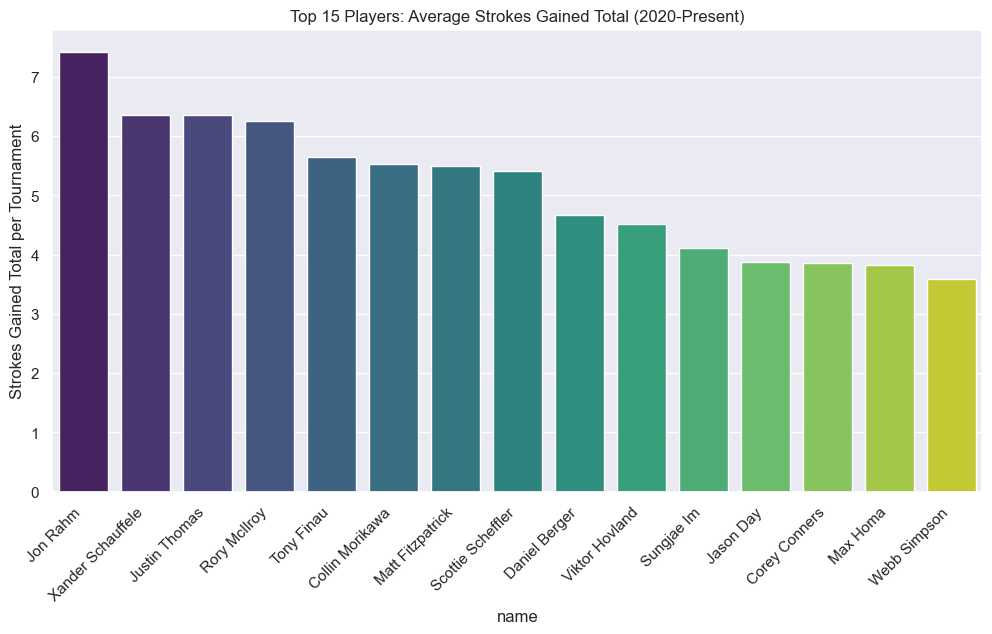

In [9]:
# Filter for recent years (2020+) to find current true skill
df_recent = df[df['season'] >= 2020].copy()

# Filter out players with < 30 tournaments
player_counts = df_recent['name'].value_counts()
valid_players = player_counts[player_counts >= 30].index
df_recent = df_recent[df_recent['name'].isin(valid_players)]

# Calculate Average Strokes Gained Total per Tournament
sg_stats = df_recent.groupby('name').agg(
    avg_sg_total=('sg_total_tournament', 'mean'),
    tournaments_played=('sg_total_tournament', 'count'),
    win_rate=('position', lambda x: (x == '1').mean() * 100)
).sort_values('avg_sg_total', ascending=False)

print("Top 15 Players by True Skill (Avg Strokes Gained Total per Tournament, 2020-Present):")
display(sg_stats.head(15).round(2))

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(x=sg_stats.head(15).index, y=sg_stats.head(15)['avg_sg_total'], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Players: Average Strokes Gained Total (2020-Present)')
plt.ylabel('Strokes Gained Total per Tournament')
plt.show()


### 3. Plotting the Baseline Math
Using your `shot_baseline.csv` and `putt_baseline.csv`, we can map out exactly how penalized a player is for missing the fairway, and how putting probability drops off. This is the math your simulation engine uses.

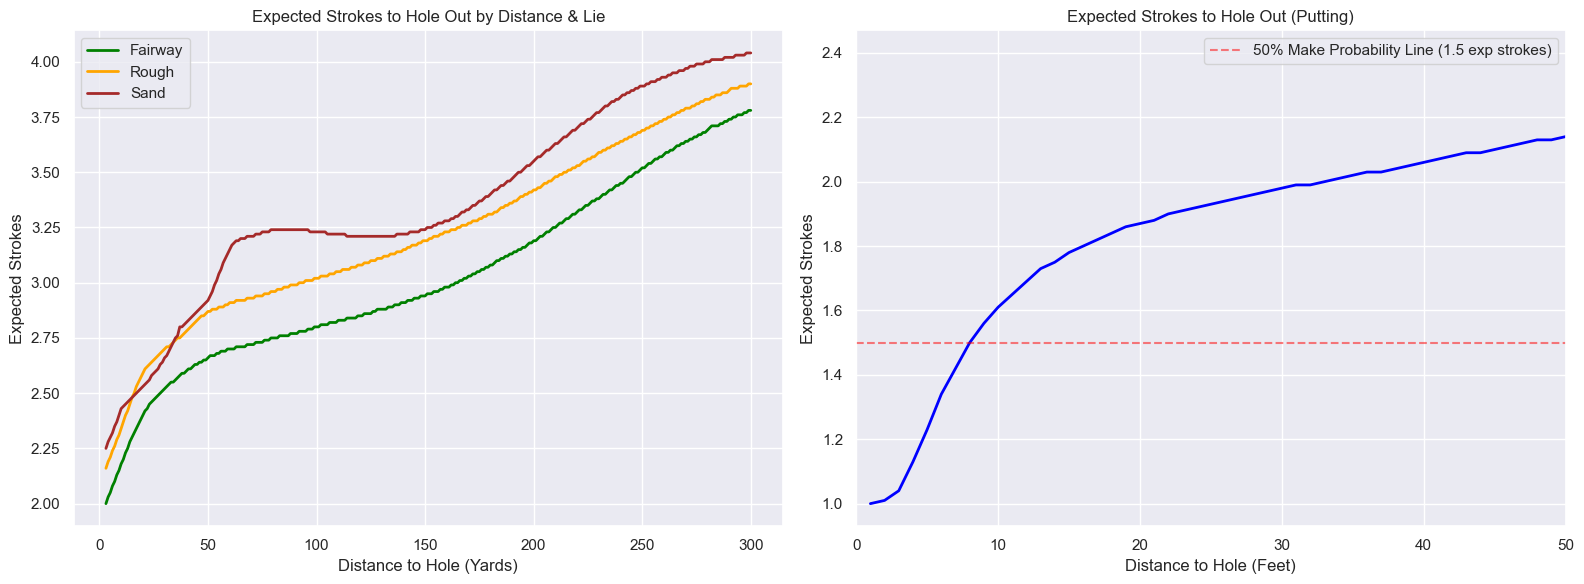

In [10]:
# Load the baseline datasets you mentioned
df_shots = pd.read_csv('../src/data/archive/shot_baseline.csv')
df_putts = pd.read_csv('../src/data/archive/putt_baseline.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Shot Difficulty by Lie
df_shots_clean = df_shots.dropna(subset=['Distance']).copy()
df_shots_clean['Distance'] = pd.to_numeric(df_shots_clean['Distance'], errors='coerce')
df_shots_clean = df_shots_clean[df_shots_clean['Distance'] <= 300] # Focus on approaches < 300 yds

ax1.plot(df_shots_clean['Distance'], df_shots_clean['Fairway'], label='Fairway', color='green', lw=2)
ax1.plot(df_shots_clean['Distance'], df_shots_clean['Rough'], label='Rough', color='orange', lw=2)
ax1.plot(df_shots_clean['Distance'], df_shots_clean['Sand'], label='Sand', color='brown', lw=2)
ax1.set_title('Expected Strokes to Hole Out by Distance & Lie')
ax1.set_xlabel('Distance to Hole (Yards)')
ax1.set_ylabel('Expected Strokes')
ax1.legend()

# Plot Putting Difficulty
ax2.plot(df_putts['Distance'], df_putts['Green'], color='blue', lw=2)
ax2.set_title('Expected Strokes to Hole Out (Putting)')
ax2.set_xlabel('Distance to Hole (Feet)')
ax2.set_ylabel('Expected Strokes')
ax2.set_xlim(0, 50) # Focus on putts inside 50 ft
ax2.axhline(1.5, color='red', linestyle='--', alpha=0.5, label='50% Make Probability Line (1.5 exp strokes)')
ax2.legend()

plt.tight_layout()
plt.show()


### 4. Regression to the Mean
If a player shoots -8 in Round 1, what happens in Round 2? We plot the correlation to prove that extreme performances violently regress, which is how you find live betting value after the cut.

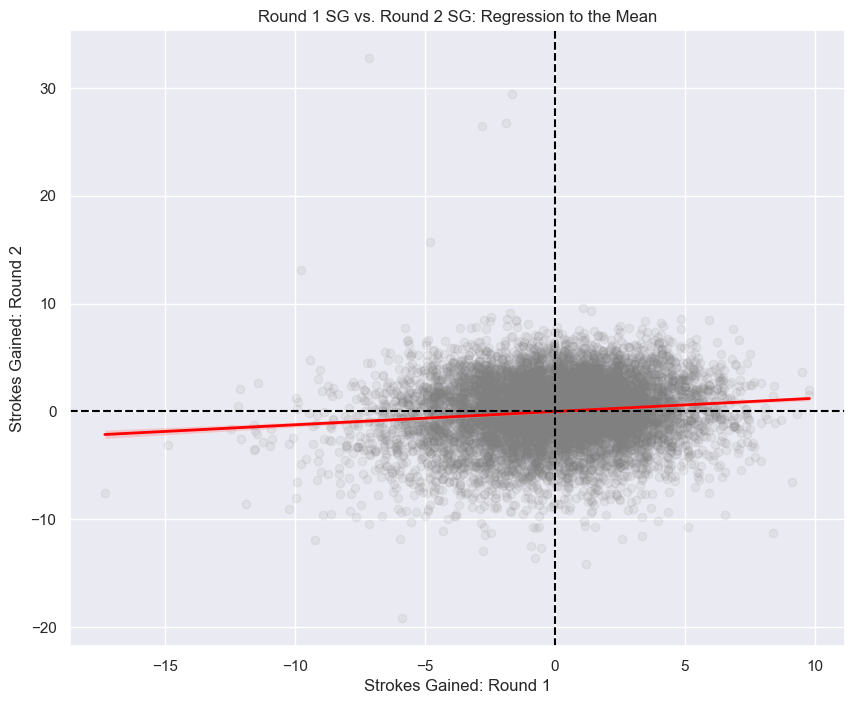

Correlation between R1 and R2 Strokes Gained: 0.116
Insight: The correlation is positive but weak. Extreme performances in R1 strongly regress toward 0 in R2.


In [11]:
# Let's look at the correlation between SG in R1 and SG in R2
# This tells us about "momentum" vs "regression to the mean"
plt.figure(figsize=(10, 8))
sample_momentum = df.dropna(subset=['sg_total_r1', 'sg_total_r2']).sample(10000, random_state=42)

sns.regplot(
    data=sample_momentum, 
    x='sg_total_r1', 
    y='sg_total_r2',
    scatter_kws={'alpha':0.1, 'color':'gray'}, 
    line_kws={'color':'red', 'lw': 2}
)
plt.title('Round 1 SG vs. Round 2 SG: Regression to the Mean')
plt.xlabel('Strokes Gained: Round 1')
plt.ylabel('Strokes Gained: Round 2')

# Add quadrant lines
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.show()

corr = sample_momentum['sg_total_r1'].corr(sample_momentum['sg_total_r2'])
print(f"Correlation between R1 and R2 Strokes Gained: {corr:.3f}")
print("Insight: The correlation is positive but weak. Extreme performances in R1 strongly regress toward 0 in R2.")


### 5. The 'Wind Grinder' Edge
We isolate rounds where wind > 15mph, and find the players who significantly *improve* their Strokes Gained in tough conditions relative to their normal baseline.

Top 10 Wind Specialists (Players who gain the most strokes vs their own baseline when it's windy):


wind_type,High Wind (>15mph),Normal Wind,wind_premium
name,,,
Jason Day,4.223,0.732,3.491
Jamie Lovemark,1.130,-1.202,2.332
Vince Whaley,1.673,-0.569,2.242
D.J. Trahan,1.802,-0.046,1.848
Seth Reeves,0.292,-1.520,1.812
Jordan Spieth,2.838,1.087,1.751
John Senden,-0.576,-2.282,1.706
Davis Riley,1.870,0.178,1.691
Maverick McNealy,1.371,-0.289,1.661


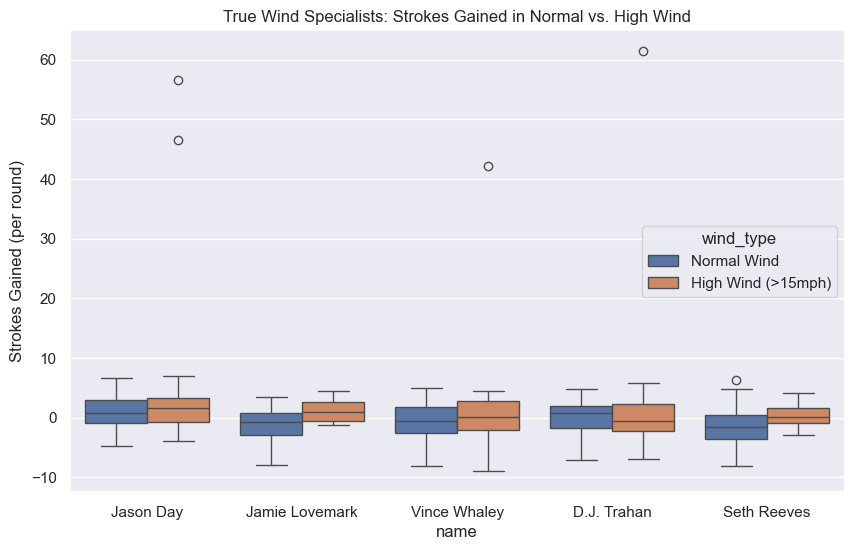

In [12]:
# Let's isolate rounds where the wind was brutal (> 15mph)
df['r1_wind'] = pd.to_numeric(df['day0wind'], errors='coerce')
df['r2_wind'] = pd.to_numeric(df['day1wind'], errors='coerce')

# Create a master dataframe of all single rounds
r1_data = df[['name', 'r1_vs_par', 'r1_wind', 'sg_total_r1', 'season']].rename(columns={'r1_vs_par':'score_to_par', 'r1_wind':'wind', 'sg_total_r1':'sg'})
r2_data = df[['name', 'r2_vs_par', 'r2_wind', 'sg_total_r2', 'season']].rename(columns={'r2_vs_par':'score_to_par', 'r2_wind':'wind', 'sg_total_r2':'sg'})

rounds_df = pd.concat([r1_data, r2_data]).dropna()
rounds_df = rounds_df[rounds_df['season'] >= 2018] # Modern era

# Categorize wind
rounds_df['wind_type'] = np.where(rounds_df['wind'] > 15, 'High Wind (>15mph)', 'Normal Wind')

# Calculate SG in normal vs high wind for each player
wind_grinders = rounds_df.groupby(['name', 'wind_type']).agg(
    avg_sg=('sg', 'mean'),
    rounds=('sg', 'count')
).reset_index()

# Filter for sample size
wind_pivot = wind_grinders.pivot(index='name', columns='wind_type', values='avg_sg')
counts_pivot = wind_grinders.pivot(index='name', columns='wind_type', values='rounds')

valid_grinders = counts_pivot[(counts_pivot['High Wind (>15mph)'] >= 10) & (counts_pivot['Normal Wind'] >= 30)].index
wind_pivot = wind_pivot.loc[valid_grinders].copy()

# Calculate "Wind Premium" (How much BETTER they play in the wind compared to their normal baseline)
wind_pivot['wind_premium'] = wind_pivot['High Wind (>15mph)'] - wind_pivot['Normal Wind']
wind_pivot = wind_pivot.sort_values('wind_premium', ascending=False)

print("Top 10 Wind Specialists (Players who gain the most strokes vs their own baseline when it's windy):")
display(wind_pivot.head(10).round(3))

# Plot the top 5
top_mudders = wind_pivot.head(5).index
plot_data = rounds_df[rounds_df['name'].isin(top_mudders)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x='name', y='sg', hue='wind_type', order=top_mudders)
plt.title('True Wind Specialists: Strokes Gained in Normal vs. High Wind')
plt.ylabel('Strokes Gained (per round)')
plt.show()


### 6. Build a Leakage-Safe Event Feature Store
We now create one row per player-tournament with features that only use information known *before* the event starts. These become your model inputs when training future-score predictors.


In [13]:
# Copy and prepare event-level outcomes

df_model = df.copy()
df_model['start'] = pd.to_datetime(df_model['start'], errors='coerce')
df_model['end'] = pd.to_datetime(df_model['end'], errors='coerce')
df_model['position_str'] = df_model['position'].astype(str).str.strip()
df_model['position_num'] = pd.to_numeric(df_model['position_str'].str.extract(r'(\d+)')[0], errors='coerce')

df_model['is_win'] = (df_model['position_str'] == '1').astype(int)
df_model['is_top5'] = (df_model['position_num'] <= 5).fillna(False).astype(int)
df_model['is_top10'] = (df_model['position_num'] <= 10).fillna(False).astype(int)
df_model['is_top20'] = (df_model['position_num'] <= 20).fillna(False).astype(int)
df_model['made_cut'] = (df_model['round3'].notna() | df_model['round4'].notna()).astype(int)

df_model['rounds_played'] = df_model[['round1', 'round2', 'round3', 'round4']].notna().sum(axis=1)
df_model['sg_total_tournament'] = df_model[['sg_total_r1', 'sg_total_r2', 'sg_total_r3', 'sg_total_r4']].sum(axis=1, min_count=1)
df_model['sg_avg_round'] = df_model[['sg_total_r1', 'sg_total_r2', 'sg_total_r3', 'sg_total_r4']].mean(axis=1)
df_model['sg_front_half'] = df_model[['sg_total_r1', 'sg_total_r2']].mean(axis=1)
df_model['sg_back_half'] = df_model[['sg_total_r3', 'sg_total_r4']].mean(axis=1)
df_model['sg_close_delta'] = df_model['sg_back_half'] - df_model['sg_front_half']
df_model['round_score_std'] = df_model[['r1_vs_par', 'r2_vs_par', 'r3_vs_par', 'r4_vs_par']].std(axis=1)

# Sort for all rolling features

df_model = df_model.sort_values(['name', 'start', 'tournament']).reset_index(drop=True)
player_group = df_model.groupby('name', sort=False)

# Career-to-date (before this event)
df_model['starts_before'] = player_group.cumcount()
df_model['prev_avg_sg_total'] = player_group['sg_total_tournament'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_avg_sg_round'] = player_group['sg_avg_round'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_avg_rounds_played'] = player_group['rounds_played'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_cut_rate'] = player_group['made_cut'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_win_rate'] = player_group['is_win'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_top5_rate'] = player_group['is_top5'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_top10_rate'] = player_group['is_top10'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_top20_rate'] = player_group['is_top20'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_avg_finish_num'] = player_group['position_num'].transform(lambda s: s.shift().expanding().mean())

df_model['prev_avg_r1_sg'] = player_group['sg_total_r1'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_avg_r4_sg'] = player_group['sg_total_r4'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_avg_close_delta'] = player_group['sg_close_delta'].transform(lambda s: s.shift().expanding().mean())

# Short-term form and trend
for window in [3, 5, 10, 20]:
    min_periods = 2 if window <= 5 else 5
    df_model[f'prev_sg_form_{window}'] = player_group['sg_avg_round'].transform(
        lambda s: s.shift().rolling(window, min_periods=min_periods).mean()
    )

df_model['prev_form_trend_5v20'] = df_model['prev_sg_form_5'] - df_model['prev_sg_form_20']
df_model['prev_round_std_10'] = player_group['round_score_std'].transform(lambda s: s.shift().rolling(10, min_periods=5).mean())

# Event history at this specific tournament (same player + tournament name)
event_group = df_model.groupby(['name', 'tournament'], sort=False)
df_model['event_starts_before'] = event_group.cumcount()
df_model['prev_event_avg_sg_round'] = event_group['sg_avg_round'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_event_cut_rate'] = event_group['made_cut'].transform(lambda s: s.shift().expanding().mean())
df_model['prev_event_top20_rate'] = event_group['is_top20'].transform(lambda s: s.shift().expanding().mean())

# Field-strength context (based on prior known skill of this week's field)
df_model['field_strength_prev_avg_sg'] = df_model.groupby(['season', 'tournament'])['prev_avg_sg_round'].transform('mean')
df_model['relative_skill_vs_field'] = df_model['prev_avg_sg_round'] - df_model['field_strength_prev_avg_sg']

# Targets for supervised learning
df_model['target_sg_total'] = df_model['sg_total_tournament']
df_model['target_sg_per_round'] = df_model['sg_avg_round']
df_model['target_made_cut'] = df_model['made_cut']
df_model['target_top10'] = df_model['is_top10']
df_model['target_top20'] = df_model['is_top20']
df_model['target_win'] = df_model['is_win']

print('Model frame prepared:', df_model.shape)


Model frame prepared: (41182, 79)


### 7. Wind Sensitivity Features (Pre-Event)
Wind can matter in certain setups, so we estimate each player's historical high-wind versus normal-wind SG edge using only prior rounds.


In [14]:
wind_round_frames = []
for round_num, sg_col, wind_col in [
    (1, 'sg_total_r1', 'day0wind'),
    (2, 'sg_total_r2', 'day1wind'),
    (3, 'sg_total_r3', 'day2wind'),
]:
    frame = df_model[['name', 'season', 'tournament', 'start', sg_col, wind_col]].copy()
    frame = frame.rename(columns={sg_col: 'sg_round', wind_col: 'wind'})
    frame['round_num'] = round_num
    wind_round_frames.append(frame)

wind_rounds = pd.concat(wind_round_frames, ignore_index=True)
wind_rounds['wind'] = pd.to_numeric(wind_rounds['wind'], errors='coerce')
wind_rounds = wind_rounds.dropna(subset=['sg_round', 'wind', 'start'])
wind_rounds = wind_rounds.sort_values(['name', 'start', 'tournament', 'round_num']).reset_index(drop=True)

wind_rounds['is_high_wind'] = wind_rounds['wind'] > 15.0
wind_rounds['sg_high_only'] = np.where(wind_rounds['is_high_wind'], wind_rounds['sg_round'], 0.0)
wind_rounds['sg_normal_only'] = np.where(~wind_rounds['is_high_wind'], wind_rounds['sg_round'], 0.0)
wind_rounds['cnt_high_only'] = wind_rounds['is_high_wind'].astype(int)
wind_rounds['cnt_normal_only'] = (~wind_rounds['is_high_wind']).astype(int)

wind_group = wind_rounds.groupby('name', sort=False)
wind_rounds['cum_sg_high_before'] = wind_group['sg_high_only'].cumsum() - wind_rounds['sg_high_only']
wind_rounds['cum_sg_normal_before'] = wind_group['sg_normal_only'].cumsum() - wind_rounds['sg_normal_only']
wind_rounds['high_wind_rounds_before'] = wind_group['cnt_high_only'].cumsum() - wind_rounds['cnt_high_only']
wind_rounds['normal_wind_rounds_before'] = wind_group['cnt_normal_only'].cumsum() - wind_rounds['cnt_normal_only']

wind_rounds['avg_sg_high_before'] = np.where(
    wind_rounds['high_wind_rounds_before'] > 0,
    wind_rounds['cum_sg_high_before'] / wind_rounds['high_wind_rounds_before'],
    np.nan,
)
wind_rounds['avg_sg_normal_before'] = np.where(
    wind_rounds['normal_wind_rounds_before'] > 0,
    wind_rounds['cum_sg_normal_before'] / wind_rounds['normal_wind_rounds_before'],
    np.nan,
)
wind_rounds['wind_premium_before'] = wind_rounds['avg_sg_high_before'] - wind_rounds['avg_sg_normal_before']

# Pull the pre-event wind state from each player's first logged round in that tournament
wind_event = (
    wind_rounds
    .sort_values(['name', 'start', 'tournament', 'round_num'])
    .groupby(['name', 'season', 'tournament', 'start'], as_index=False)
    .first()[[
        'name', 'season', 'tournament', 'start', 'wind_premium_before',
        'high_wind_rounds_before', 'normal_wind_rounds_before'
    ]]
)

df_model = df_model.drop(columns=['wind_premium_before', 'high_wind_rounds_before', 'normal_wind_rounds_before'], errors='ignore')
df_model = df_model.merge(
    wind_event,
    on=['name', 'season', 'tournament', 'start'],
    how='left',
)

df_model['wind_feature_ready'] = (
    (df_model['high_wind_rounds_before'] >= 10) &
    (df_model['normal_wind_rounds_before'] >= 30)
).astype(int)

print('Wind features merged:', df_model[['wind_premium_before', 'wind_feature_ready']].notna().mean().to_dict())


Wind features merged: {'wind_premium_before': 0.9403137292992084, 'wind_feature_ready': 1.0}


### 8. Assemble the Training Table and Export
This table is your portable feature store for ensemble training on your PC.


In [15]:
identity_cols = [
    'season', 'start', 'end', 'tournament', 'location', 'name',
    'position_str', 'position_num', 'rounds_played', 'Course Par'
]

feature_cols = [
    'starts_before',
    'prev_avg_sg_total', 'prev_avg_sg_round', 'prev_avg_rounds_played',
    'prev_cut_rate', 'prev_win_rate', 'prev_top5_rate', 'prev_top10_rate', 'prev_top20_rate',
    'prev_avg_finish_num',
    'prev_avg_r1_sg', 'prev_avg_r4_sg', 'prev_avg_close_delta',
    'prev_sg_form_3', 'prev_sg_form_5', 'prev_sg_form_10', 'prev_sg_form_20',
    'prev_form_trend_5v20', 'prev_round_std_10',
    'event_starts_before', 'prev_event_avg_sg_round', 'prev_event_cut_rate', 'prev_event_top20_rate',
    'field_strength_prev_avg_sg', 'relative_skill_vs_field',
    'wind_premium_before', 'high_wind_rounds_before', 'normal_wind_rounds_before', 'wind_feature_ready'
]

target_cols = [
    'target_sg_total', 'target_sg_per_round', 'target_made_cut',
    'target_top10', 'target_top20', 'target_win'
]

selected_cols = [c for c in identity_cols + feature_cols + target_cols if c in df_model.columns]
feature_store = df_model[selected_cols].copy()

# Keep all rows, but add history quality flags for filtering during model training
feature_store['history_5_plus'] = (feature_store['starts_before'] >= 5).astype(int)
feature_store['history_20_plus'] = (feature_store['starts_before'] >= 20).astype(int)

# Time-based split suggestion (adjust as needed)
feature_store['dataset_split'] = np.select(
    [
        feature_store['start'] < pd.Timestamp('2022-01-01'),
        (feature_store['start'] >= pd.Timestamp('2022-01-01')) & (feature_store['start'] < pd.Timestamp('2024-01-01')),
        feature_store['start'] >= pd.Timestamp('2024-01-01'),
    ],
    ['train', 'valid', 'test'],
    default='train'
)

output_dir = Path('./cache')
output_dir.mkdir(parents=True, exist_ok=True)

csv_path = output_dir / 'pga_feature_store_event_level.csv'
parquet_path = output_dir / 'pga_feature_store_event_level.parquet'
feature_store.to_csv(csv_path, index=False)

parquet_ok = True
try:
    feature_store.to_parquet(parquet_path, index=False)
except Exception as exc:
    parquet_ok = False
    print('Parquet export skipped:', exc)

print('Feature store shape:', feature_store.shape)
print('Numeric feature count:', feature_store.select_dtypes(include=[np.number]).shape[1])
print('CSV:', csv_path)
print('Parquet:', parquet_path if parquet_ok else 'not written')

display(feature_store.head(10))


Feature store shape: (41182, 48)
Numeric feature count: 41
CSV: cache/pga_feature_store_event_level.csv
Parquet: cache/pga_feature_store_event_level.parquet


,season,start,end,tournament,location,name,position_str,position_num,rounds_played,Course Par,...,wind_feature_ready,target_sg_total,target_sg_per_round,target_made_cut,target_top10,target_top20,target_win,history_5_plus,history_20_plus,dataset_split
0,2022,2022-06-09,2022-06-12,RBC Canadian Open,"St. George's Golf and Country Club - Toronto, ON",A.J. Ewart (a),CUT,NaN,2,70,...,0,-1.821053,-0.910526,0,0,0,0,0,0,valid
1,2009,2009-01-29,2009-02-01,FBR Open,"TPC Scottsdale (Stadium Course) - Scottsdale, AZ",Aaron Baddeley,T35,35.0,4,71,...,0,2.964060,0.741015,1,0,0,0,0,0,train
2,2009,2009-02-05,2009-02-08,Buick Invitational,"Torrey Pines (North Course) - La Jolla, CA",Aaron Baddeley,T11,11.0,4,72,...,0,8.283085,2.070771,1,0,1,0,0,0,train
3,2009,2009-02-19,2009-02-22,Northern Trust Open,"Riviera Country Club - Pacific Palisades, CA",Aaron Baddeley,T51,51.0,4,71,...,0,0.989354,0.247339,1,0,0,0,0,0,train
4,2009,2009-04-02,2009-04-05,Shell Houston Open,"Golf Club of Houston - Houston, TX",Aaron Baddeley,CUT,NaN,2,72,...,0,-3.207143,-1.603571,0,0,0,0,0,0,train
5,2009,2009-04-09,2009-04-12,The Masters,"Augusta National Golf Club - Augusta, GA",Aaron Baddeley,T17,17.0,4,72,...,0,5.709583,1.427396,1,0,1,0,0,0,train
6,2009,2009-04-16,2009-04-19,Verizon Heritage,"Harbour Town Golf Links - Hilton Head Island, SC",Aaron Baddeley,T21,21.0,4,71,...,0,5.323077,1.330769,1,0,0,0,1,0,train
7,2009,2009-04-30,2009-05-03,Quail Hollow Championship,"Quail Hollow Club - Charlotte, NC",Aaron Baddeley,CUT,NaN,2,72,...,0,-4.086093,-2.043046,0,0,0,0,1,0,train
8,2009,2009-05-07,2009-05-10,THE PLAYERS Championship,TPC Sawgrass (THE PLAYERS Stadium Course) - Po...,Aaron Baddeley,T9,9.0,4,72,...,0,7.457315,1.864329,1,1,1,0,1,0,train
9,2009,2009-06-04,2009-06-07,the Memorial Tournament,"Muirfield Village Golf Club - Dublin, OH",Aaron Baddeley,CUT,NaN,2,72,...,0,-6.119658,-3.059829,0,0,0,0,1,0,train


### 9. Quick Signal Check for Intuitive Features
This is a fast sanity check so you can see which engineered features have the strongest monotonic relationship with outcomes.


In [16]:
signal_features = [
    'prev_avg_sg_round', 'prev_cut_rate', 'prev_top10_rate', 'prev_top20_rate',
    'prev_sg_form_5', 'prev_form_trend_5v20', 'prev_event_avg_sg_round',
    'relative_skill_vs_field', 'wind_premium_before'
]

available_signals = [c for c in signal_features if c in feature_store.columns]

for target in ['target_win', 'target_top10', 'target_sg_per_round']:
    check_cols = [c for c in available_signals if c in feature_store.columns] + [target]
    signal_df = feature_store[check_cols].dropna()
    if signal_df.empty:
        print(f'No rows available for {target} correlation check.')
        continue

    corr = signal_df.corr(numeric_only=True)[target].drop(labels=[target]).sort_values(ascending=False)
    print(f'\nTop correlations with {target}:')
    display(corr.head(10).round(3).to_frame('corr'))



Top correlations with target_win:


,corr
prev_top10_rate,0.090
prev_top20_rate,0.086
prev_avg_sg_round,0.071
relative_skill_vs_field,0.070
prev_sg_form_5,0.063
prev_cut_rate,0.059
prev_event_avg_sg_round,0.038
prev_form_trend_5v20,0.009
wind_premium_before,-0.005



Top correlations with target_top10:


,corr
prev_top20_rate,0.201
prev_top10_rate,0.199
relative_skill_vs_field,0.186
prev_avg_sg_round,0.182
prev_sg_form_5,0.165
prev_cut_rate,0.152
prev_event_avg_sg_round,0.085
prev_form_trend_5v20,0.039
wind_premium_before,-0.000



Top correlations with target_sg_per_round:


,corr
relative_skill_vs_field,0.267
prev_avg_sg_round,0.255
prev_sg_form_5,0.245
prev_top20_rate,0.238
prev_top10_rate,0.222
prev_cut_rate,0.219
prev_event_avg_sg_round,0.141
prev_form_trend_5v20,0.070
wind_premium_before,-0.002
